In [2]:
import numpy as np
from orphics import maps
from pixell import enmap, utils
from pixell import curvedsky as cs
import healpy as hp
import time
import argparse
import camb
import matplotlib.pyplot as plt

In [4]:
nsims = 1

lmax = 4000
l = np.linspace(0,lmax,lmax+1)

noiselevel = 10

sim_idx = 1

In [5]:

# get map geometry for 2 arcmin resolution
res = 2.0 * utils.arcmin
box = np.deg2rad([[-10, -10], [10, 10]])

shape, wcs = enmap.geometry(pos=box, res=res)

# add 3 to shape. This is necessary for the pipeline. 
shape = (3,) + shape

In [6]:
# load up CMB power spectrum from CAMB

pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
pars.InitPower.set_params(As=2.1e-9, ns=0.965)
pars.set_for_lmax(lmax, lens_potential_accuracy=1)

results = camb.get_results(pars)

cmb_ps = results.get_cmb_power_spectra(pars, CMB_unit="muK", raw_cl=True)["total"]

cl_tt = cmb_ps[:lmax + 1, 0]

Text(0, 0.5, '$C_\\ell^{\\tau \\tau}$')

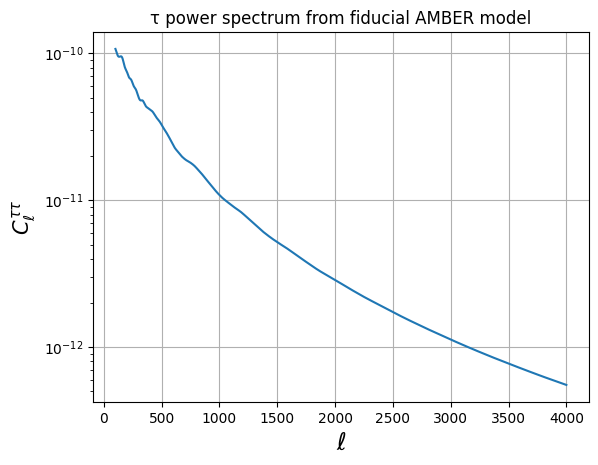

In [10]:
# Load up tau theory curve

"""This input optical-depth power spectrum is derived from a simulation generated by the publicly available AMBER pipeline (Trac et al. 2022)
    and is used to generate Gaussian realizations of the patchy optical-depth field based on given input reionization parameters.
    The parameters chosen for this power spectrum are as follows:
    midpoint reionization redshift, z_mid = 8
    middle 90% of the redshift duration of reionization, Δz = 4
    redshift asymmetry parameter, A_z = 3
    minimum halo mass required to produce ionizing radiation, M_min = 10^8 M_sun
    mean-free path of ionizing photons, λ = 3 Mpc/h"""

tau_ells, cl_tau = np.loadtxt("cmb-screening-demo/data/cl_tau.txt", unpack=True, skiprows=1)

mask = tau_ells <= lmax

tau_ells_use = tau_ells[mask].astype(int)
cl_tau_use = cl_tau[mask]

cl_tau_full = np.zeros(lmax + 1)
cl_tau_full[tau_ells_use] = cl_tau_use

# check out the power spectrum, in log(y) axis to see the full shape:
plt.figure()
plt.title("τ power spectrum from fiducial AMBER model")
plt.semilogy(tau_ells_use, cl_tau_use)
plt.grid()
plt.xlabel(r"$\ell$", fontsize=17)
plt.ylabel(r"$C_\ell^{\tau \tau}$", fontsize=15)

In [8]:

for i in range(nsims):
    # make tau simulation from fiducial power spectrum
    taualm1 = cs.rand_alm(cl_tau, lmax=lmax)
    tauzeros = np.zeros_like(taualm1)

    taualm = np.array([taualm1,tauzeros,tauzeros])
    
    # make CMB sim, one TT and blank E and B
    cmbalm1 = cs.rand_alm(cl_tt, lmax=lmax)
    cmbzeros = np.zeros_like(cmbalm1)

    cmbalm = np.array([cmbalm1, cmbzeros, cmbzeros])
    
    assert len(cmbalm)==3

    # move to real space to do the modulation so no convolutions
    cmbmap = cs.alm2map(cmbalm, enmap.ndmap(np.zeros(shape),wcs))
    taumap = cs.alm2map(taualm, enmap.ndmap(np.zeros(shape),wcs))

    taucmb_map = cmbmap*np.exp(-taumap)
    taucmb_alm = cs.map2alm(taucmb_map,lmax=lmax)
    assert len(taucmb_alm)==3

    # make CMB sim, with white noise added
    # making 1 noise realization per simulation 

    # N_l = (Delta_T * pi / (180 * 60))^2 / B_l^2
    noise_ps = (noiselevel * np.pi / (180 * 60))**2 / maps.gauss_beam(l, 1.4)**2

    onesarray = np.ones(hp.Alm.getsize(lmax))
    three_onesarray = (onesarray,onesarray,onesarray)
    nalm = cs.rand_alm(noise_ps,lmax=lmax)*three_onesarray
    
    print("len nalm = "+str(len(nalm)))
    cmb_noisy_alm = np.add(taucmb_alm,nalm)

    print("shape of cmb noise alms (should be (3,almlen): "+str(np.shape(cmb_noisy_alm)))

    # hp.write_alm(save_path+"fullskyTauedCMB_noise%s_alm_%s.fits"%(str(noiselevel),istr), cmb_noisy_alm,overwrite=True)

len nalm = 3
shape of cmb noise alms (should be (3,almlen): (3, 8006001)
